In [21]:
import numpy as np
from scipy.optimize import root
from scipy.linalg import solve
import matplotlib.pyplot as plt

# -----------------------------
# Constants
# -----------------------------
Gamma = 2*np.pi*6e6      # rad/s
Gamma2 = Gamma
Gamma3 = Gamma
Gamma4 = Gamma/3
gamma = 0.4*Gamma

# Example Rabi frequencies
Omega_c = 17*Gamma
Omega_p = 78*Gamma

# Wavevector ratios
kp_over_kc = 795/1476    # approx kc/kp? adjust carefully using k = 2pi/lambda
ks_over_kc = 795/1529    # adjust based on paper convention

Zeroth order OBEs

In [22]:
def unpack_zeroth(x):
    rho11, rho22, rho33, rho44 = x[0:4]
    rho21 = x[4] + 1j*x[5]
    rho42 = x[6] + 1j*x[7]
    rho41 = x[8] + 1j*x[9]
    return rho11, rho22, rho33, rho44, rho21, rho42, rho41


def zeroth_obe_residual(
    x, Delta_c, Delta_p, omega_D,
    Omega_c, Omega_p,
    Gamma2, Gamma3, Gamma4, gamma
):
    rho11, rho22, rho33, rho44, rho21, rho42, rho41 = unpack_zeroth(x)

    eqs = []

    # A1
    eqs.append(rho11 + rho22 + rho33 + rho44 - 1)

    # A2
    A2 = (
        -Gamma2*rho22
        + (Gamma4/2)*rho44
        + 0.5j*(Omega_c*np.conj(rho21) - np.conj(Omega_c)*rho21
                + np.conj(Omega_p)*rho42 - Omega_p*np.conj(rho42))
    )
    eqs.append(A2)

    # A3
    A3 = -Gamma3*rho33 + (Gamma4/2)*rho44
    eqs.append(A3)

    # A4
    A4 = (
        -Gamma4*rho44
        + 0.5j*(Omega_p*np.conj(rho42) - np.conj(Omega_p)*rho42)
    )
    eqs.append(A4)

    # A5
    A5 = (
        1j*(Delta_c - omega_D)*rho21
        - (Gamma2/2 + gamma)*rho21
        + 0.5j*(Omega_c*rho11 - Omega_c*rho22 + np.conj(Omega_p)*rho41)
    )
    eqs.append(A5)

    # A6
    A6 = (
        1j*(Delta_p - kp_over_kc*omega_D)*rho42
        - (Gamma2/2 + Gamma4/2 + gamma)*rho42
        + 0.5j*(Omega_p*rho22 - Omega_p*rho44 - np.conj(Omega_c)*rho41)
    )
    eqs.append(A6)

    # A7
    A7 = (
        1j*(Delta_c - omega_D + Delta_p - kp_over_kc*omega_D)*rho41
        - (Gamma4/2 + gamma)*rho41
        + 0.5j*(Omega_p*rho21 - Omega_c*rho42)
    )
    eqs.append(A7)

    # Convert complex equations to real equations
    residual = []
    for eq in eqs:
        residual.append(np.real(eq))
        if np.iscomplexobj(eq):
            residual.append(np.imag(eq))

    # We currently have too many real equations because A1-A4 are real.
    # So return manually:
    return np.array([
        np.real(eqs[0]),
        np.real(eqs[1]),
        np.real(eqs[2]),
        np.real(eqs[3]),
        np.real(eqs[4]), np.imag(eqs[4]),
        np.real(eqs[5]), np.imag(eqs[5]),
        np.real(eqs[6]), np.imag(eqs[6]),
    ])


def solve_zeroth_obes(Delta_c, Delta_p, omega_D):
    x0 = np.zeros(10)
    x0[0] = 1.0  # start mostly in ground state

    sol = root(
        zeroth_obe_residual,
        x0,
        args=(Delta_c, Delta_p, omega_D,
              Omega_c, Omega_p,
              Gamma2, Gamma3, Gamma4, gamma),
        method="hybr"
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return unpack_zeroth(sol.x)

First Order OBEs

In [23]:
def solve_first_order_full(
    rho0,
    Delta_c, Delta_p, Delta_s, omega_D,
    Omega_s, Omega_s_conj,
    Omega_i, Omega_i_conj
):
    rho11, rho22, rho33, rho44, rho21, rho42, rho41 = rho0

    # Unknowns:
    # x[0] = rho43
    # x[1] = rho32
    # x[2] = rho31
    # x[3] = rho43*
    # x[4] = rho32*
    # x[5] = rho31*

    M = np.zeros((6, 6), dtype=complex)
    b = np.zeros(6, dtype=complex)

    # -----------------------
    # A8: rho43
    # -----------------------
    A43 = (
        1j*(Delta_s - ks_over_kc*omega_D)
        - (Gamma3/2 + Gamma4/2 + gamma)
    )

    M[0, 0] = A43
    M[0, 4] = 0.5j * Omega_p          # Omega_p rho32*
    b[0] = -0.5j * (
        Omega_s*rho33
        - Omega_s*rho44
        - Omega_i_conj*rho41
    )

    # -----------------------
    # A9: rho32
    # -----------------------
    A32 = (
        1j*(Delta_p - kp_over_kc*omega_D
            - Delta_s + ks_over_kc*omega_D)
        - (Gamma3/2 + Gamma2/2 + gamma)
    )

    M[1, 1] = A32
    M[1, 2] = -0.5j * np.conj(Omega_c)
    M[1, 3] = -0.5j * Omega_p          # -Omega_p rho43*
    b[1] = -0.5j * (
        Omega_s_conj*rho42
        + Omega_i*np.conj(rho21)
    )

    # -----------------------
    # A10: rho31
    # -----------------------
    A31 = (
        1j*(Delta_c - omega_D
            + Delta_p - kp_over_kc*omega_D
            - Delta_s + ks_over_kc*omega_D)
        - (Gamma3/2 + gamma)
    )

    M[2, 2] = A31
    M[2, 1] = -0.5j * Omega_c
    b[2] = -0.5j * (
        Omega_i*rho11
        - Omega_i*rho33
        + Omega_s_conj*rho41
    )

    # -----------------------
    # Conjugate of A8
    # -----------------------
    M[3, 3] = np.conj(A43)
    M[3, 1] = -0.5j * np.conj(Omega_p)
    b[3] = +0.5j * (
        Omega_s_conj*rho33
        - Omega_s_conj*rho44
        - Omega_i*np.conj(rho41)
    )

    # -----------------------
    # Conjugate of A9
    # -----------------------
    M[4, 4] = np.conj(A32)
    M[4, 5] = +0.5j * Omega_c
    M[4, 0] = +0.5j * np.conj(Omega_p)
    b[4] = +0.5j * (
        Omega_s*np.conj(rho42)
        + Omega_i_conj*rho21
    )

    # -----------------------
    # Conjugate of A10
    # -----------------------
    M[5, 5] = np.conj(A31)
    M[5, 4] = +0.5j * np.conj(Omega_c)
    b[5] = +0.5j * (
        Omega_i_conj*rho11
        - Omega_i_conj*rho33
        + Omega_s*np.conj(rho41)
    )

    x = np.linalg.solve(M, b)

    rho43 = x[0]
    rho32 = x[1]
    rho31 = x[2]

    return rho43, rho32, rho31

Solving PDEs

In [24]:
def compute_susceptibility_derivatives(
    Delta_c, Delta_p, Delta_s, omega_D
):
    rho0 = solve_zeroth_obes(Delta_c, Delta_p, omega_D)

    # d rho31 / d Omega_s*
    _, _, rho31 = solve_first_order_full(
        rho0, Delta_c, Delta_p, Delta_s, omega_D,
        Omega_s=0.0,
        Omega_s_conj=1.0,
        Omega_i=0.0,
        Omega_i_conj=0.0
    )
    d_rho31_d_Omega_s_conj = rho31

    # d rho43 / d Omega_s
    rho43, _, _ = solve_first_order_full(
        rho0, Delta_c, Delta_p, Delta_s, omega_D,
        Omega_s=1.0,
        Omega_s_conj=0.0,
        Omega_i=0.0,
        Omega_i_conj=0.0
    )
    d_rho43_d_Omega_s = rho43

    # d rho31 / d Omega_i
    _, _, rho31 = solve_first_order_full(
        rho0, Delta_c, Delta_p, Delta_s, omega_D,
        Omega_s=0.0,
        Omega_s_conj=0.0,
        Omega_i=1.0,
        Omega_i_conj=0.0
    )
    d_rho31_d_Omega_i = rho31

    return (
        d_rho31_d_Omega_s_conj,
        d_rho43_d_Omega_s,
        d_rho31_d_Omega_i
    )

Solving the Integrals

In [30]:
import numpy as np

# -----------------------------
# Gaussian Doppler weight
# -----------------------------
def doppler_weight(wD, Gamma_D):
    return np.exp(-(wD/Gamma_D)**2) / (np.sqrt(np.pi) * Gamma_D)


# -----------------------------
# Eq. A12-A14
# -----------------------------
def susceptibility_integrals(
    Delta_c,
    Delta_p,
    Delta_s,
    alpha,
    Gamma,
    Gamma_D,
    wD_points=401,
    wD_span=6
):
    wD_grid = np.linspace(-wD_span*Gamma_D, wD_span*Gamma_D, wD_points)

    kappa_integrand = np.zeros(wD_points, dtype=complex)
    zeta_integrand  = np.zeros(wD_points, dtype=complex)
    xi_integrand    = np.zeros(wD_points, dtype=complex)

    for j, wD in enumerate(wD_grid):

        (
            d_rho31_d_Omega_s_conj,
            d_rho43_d_Omega_s,
            d_rho31_d_Omega_i
        ) = compute_susceptibility_derivatives(
            Delta_c=Delta_c,
            Delta_p=Delta_p,
            Delta_s=Delta_s,
            omega_D=wD
        )

        W = doppler_weight(wD, Gamma_D)

        # Eq. A12
        kappa_integrand[j] = W * d_rho31_d_Omega_s_conj

        # Eq. A13
        zeta_integrand[j] = W * d_rho43_d_Omega_s

        # Eq. A14
        xi_integrand[j] = W * d_rho31_d_Omega_i

    prefactor = alpha * Gamma / 4

    kappa_bar = prefactor * np.trapz(kappa_integrand, wD_grid)
    zeta_bar  = prefactor * np.trapz(zeta_integrand,  wD_grid)
    xi_bar    = prefactor * np.trapz(xi_integrand,    wD_grid)

    return kappa_bar, zeta_bar, xi_bar

Calculate Biphoton Spectrum

In [31]:
def compute_F_spectrum(
    Delta_c,
    Delta_p,
    alpha,
    Gamma,
    Gamma_D,
    Delta_s_max=2*np.pi*500e6,
    N_Delta_s=401
):
    Delta_s_grid = np.linspace(-Delta_s_max, Delta_s_max, N_Delta_s)

    kappa_arr = np.zeros(N_Delta_s, dtype=complex)
    zeta_arr  = np.zeros(N_Delta_s, dtype=complex)
    xi_arr    = np.zeros(N_Delta_s, dtype=complex)
    F_arr     = np.zeros(N_Delta_s, dtype=complex)

    for j, Delta_s in enumerate(Delta_s_grid):

        kappa_bar, zeta_bar, xi_bar = susceptibility_integrals(
            Delta_c=Delta_c,
            Delta_p=Delta_p,
            Delta_s=Delta_s,
            alpha=alpha,
            Gamma=Gamma,
            Gamma_D=Gamma_D
        )

        kappa_arr[j] = kappa_bar
        zeta_arr[j]  = zeta_bar
        xi_arr[j]    = xi_bar

        # Eq. A16
        F_arr[j] = (
            kappa_bar
            * np.sinc((zeta_bar + xi_bar)/np.pi)
            * np.exp(1j * xi_bar)
        )

    return Delta_s_grid, F_arr, kappa_arr, zeta_arr, xi_arr

G2 spectrum

In [32]:
def compute_G2_from_F(Delta_s_grid, F_arr, t_grid):
    dDelta_s = Delta_s_grid[1] - Delta_s_grid[0]

    psi = np.zeros_like(t_grid, dtype=complex)

    for m, t in enumerate(t_grid):
        psi[m] = np.sum(
            F_arr * np.exp(1j * Delta_s_grid * t)
        ) * dDelta_s / (2*np.pi)

    G2 = np.abs(psi)**2

    # normalize for plotting
    G2 = G2 / np.max(G2)

    return G2

In [33]:
Gamma = 2*np.pi*6e6
Gamma_D = 2*np.pi*320e6

alpha = 420

Delta_c = 2*np.pi*2.28e9
Delta_p = -Delta_c   # example only; set using paper's omegaD0 and Delta_atom

Delta_s_grid, F, kappa, zeta, xi = compute_F_spectrum(
    Delta_c=Delta_c,
    Delta_p=Delta_p,
    alpha=alpha,
    Gamma=Gamma,
    Gamma_D=Gamma_D,
    Delta_s_max=2*np.pi*500e6,
    N_Delta_s=401
)

t_grid = np.linspace(-20e-9, 100e-9, 401)

G2 = compute_G2_from_F(
    Delta_s_grid=Delta_s_grid,
    F_arr=F,
    t_grid=t_grid
)

C:\Users\ChoyLab\AppData\Local\Temp\ipykernel_22188\12961521.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  kappa_bar = prefactor * np.trapz(kappa_integrand, wD_grid)
C:\Users\ChoyLab\AppData\Local\Temp\ipykernel_22188\12961521.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zeta_bar  = prefactor * np.trapz(zeta_integrand,  wD_grid)
C:\Users\ChoyLab\AppData\Local\Temp\ipykernel_22188\12961521.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  xi_bar    = prefactor * np.trapz(xi_integrand,    wD_grid)


In [34]:
def apply_etalons(F_arr, Delta_s_grid):
    Tp = 0.29
    Gamma_e = 2*np.pi*59e6
    return F_arr * np.sqrt(Tp) / (1 + 4*Delta_s_grid**2/Gamma_e**2)

In [35]:
F_etalon = apply_etalons(F, Delta_s_grid)

G2_etalon = compute_G2_from_F(
    Delta_s_grid=Delta_s_grid,
    F_arr=F_etalon,
    t_grid=t_grid
)

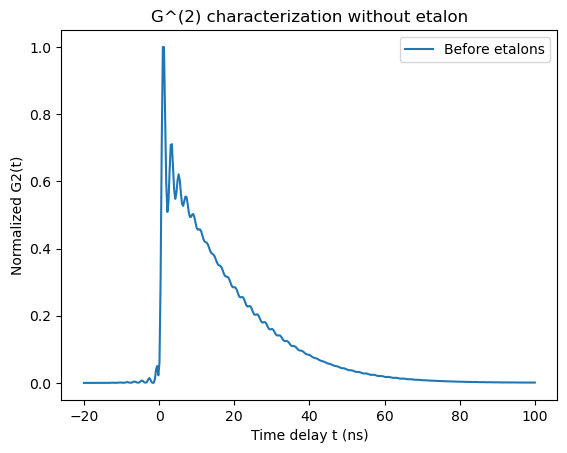

In [36]:
import matplotlib.pyplot as plt

plt.plot(t_grid*1e9, G2, label="Before etalons")
# plt.plot(t_grid*1e9, G2_etalon, label="After etalons")
plt.xlabel("Time delay t (ns)")
plt.ylabel("Normalized G2(t)")
plt.legend()
plt.title("G^(2) characterization without etalon")
plt.show()

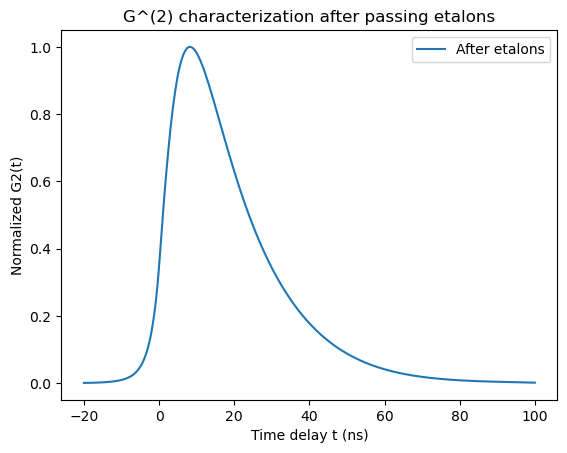

In [37]:


# plt.plot(t_grid*1e9, G2, label="Before etalons")
plt.plot(t_grid*1e9, G2_etalon, label="After etalons")
plt.xlabel("Time delay t (ns)")
plt.ylabel("Normalized G2(t)")
plt.title("G^(2) characterization after passing etalons")
plt.legend()
plt.show()


In [38]:
import numpy as np

def extract_fwhm(t_grid, G2):
    """
    t_grid in seconds.
    G2 can be normalized or unnormalized.
    Returns FWHM in seconds.
    """

    G2 = np.asarray(G2)
    t_grid = np.asarray(t_grid)

    # Normalize
    y = G2 / np.max(G2)

    half_max = 0.5

    # Find peak
    peak_idx = np.argmax(y)

    # Left crossing
    left_indices = np.where(y[:peak_idx] < half_max)[0]
    if len(left_indices) == 0:
        raise ValueError("No left half-maximum crossing found.")

    i1 = left_indices[-1]
    i2 = i1 + 1

    t_left = np.interp(
        half_max,
        [y[i1], y[i2]],
        [t_grid[i1], t_grid[i2]]
    )

    # Right crossing
    right_indices = np.where(y[peak_idx:] < half_max)[0]
    if len(right_indices) == 0:
        raise ValueError("No right half-maximum crossing found.")

    i2 = peak_idx + right_indices[0]
    i1 = i2 - 1

    t_right = np.interp(
        half_max,
        [y[i1], y[i2]],
        [t_grid[i1], t_grid[i2]]
    )

    fwhm = t_right - t_left

    return fwhm, t_left, t_right

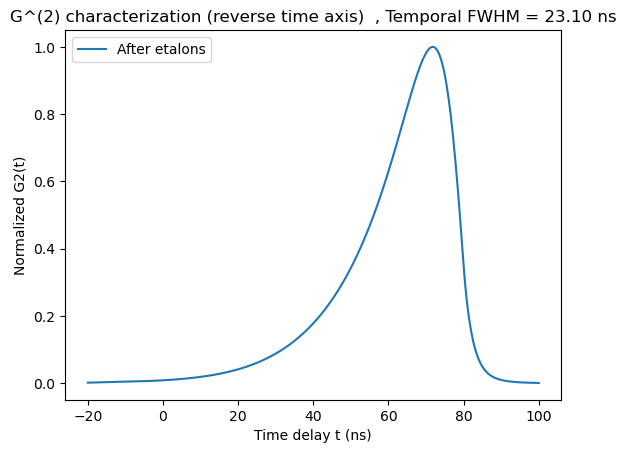

In [43]:
import matplotlib.pyplot as plt

fwhm, t_left, t_right = extract_fwhm(t_grid, G2_etalon)

plt.plot(t_grid*1e9, G2_etalon[::-1], label="After etalons")
# plt.axhline(0.5, linestyle="--", label="Half maximum")
# plt.axvline(t_left*1e9, linestyle="--")
# plt.axvline(t_right*1e9, linestyle="--")

plt.xlabel("Time delay t (ns)")
plt.ylabel("Normalized G2(t)")
plt.title("G^(2) characterization (reverse time axis) "+" , " f"Temporal FWHM = {fwhm*1e9:.2f} ns")
plt.legend()
plt.show()